## Imports

In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from graphviz import Digraph
from IPython.display import display

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

In [2]:
# Setup (Colab only)
if 'google.colab' in sys.modules:
    if not os.path.exists("decision-tree-from-scratch-analysis"):
        !git clone https://github.com/maytko-svg/decision-tree-from-scratch-analysis.git
    %cd decision-tree-from-scratch-analysis
    sys.path.append('/content/decision-tree-from-scratch-analysis')

/content/decision-tree-from-scratch-analysis


In [3]:
from src.id3 import id3
from src.pruning import id3_pruned
from src.evaluation import (
    get_predictions,
    evaluate,
    plot_confusion_matrix
)

## Load Dataset

In [4]:
# Load Wine dataset and convert to DataFrame for easier manipulation
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

**Split into training and testing sets**

In [5]:
# Train/test split (70/30)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

## Implementation

**Tree visualization function**

In [6]:
def draw_tree(tree, parent_name="", graph=None):
  if graph is None:
    # Initialise Graphviz object on first call
    graph = Digraph(format="png")
    graph.attr("node", shape="ellipse", fontsize="12")

  # Tree represented as nested dictionaries: {features: {value: subtree_or_label}}
  if isinstance(tree, dict):
    root = next(iter(tree)) # current feature
    children = tree[root]

    graph.node(root, root)

    # Connect node to parent node if not root of entire tree
    if parent_name:
      graph.edge(parent_name, root)

    # Traverse branches
    for branch_value, subtree in children.items():
      child_name = f"{root}_{branch_value}"  # unique identifier to prevent node name collisions

      if isinstance(subtree, dict):
        # Internal node: create edge label and recurse deeper
        graph.node(child_name, f"{branch_value}")
        graph.edge(root, child_name)

        # Recursive call to build subtree
        draw_tree(subtree, child_name, graph)

      else:
        # Leaf node: contains final class prediction
        leaf_name = f"{child_name}_leaf"
        graph.node(leaf_name, f"{branch_value} -> {subtree}", shape="box", style="filled", color="lightgrey")
        graph.edge(root, leaf_name)

  return graph

## Experiments

### Plain ID3 Decision Tree with Modifications

####Plain ID3 (Baseline Model)

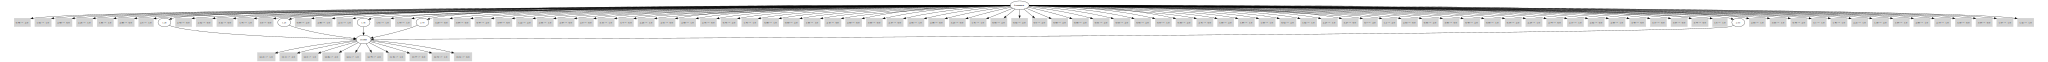

Configuration,Accuracy,Precision,Recall,F1
id3_plain,0.444444,0.561538,0.437761,0.420292


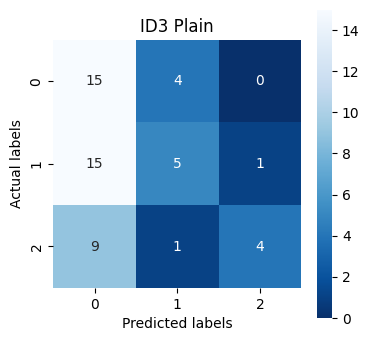

In [7]:
# Convert DataFrame into list-of-lists format required by custom ID3 implementation
train_dataset = train_df.values.tolist()
test_dataset = test_df.values.tolist()

# Train Plain ID3 (baseline model with no pruning)
target_index = len(train_dataset[0]) - 1
tree = id3(train_dataset, target_index, features=feature_names[:])

# Visualise tree to inspect learned decision splits
graph = draw_tree(tree)
display(graph)
graph.render("outputs/trees/id3_plain", format="png", cleanup=True)

# Generate predictions and evaluate performance
y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_plain = evaluate("id3_plain", y_true, y_pred)

# Display results and plot confusion matrix to analyse class-wise performance and misclassifications
display(pd.DataFrame([results_plain]).style.hide(axis="index"))

plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Plain",
    save_path="outputs/confusion_matrices/01_plain.png",
    show=True
)

**Observation:**  

Baseline ID3 performs poorly because it cannot directly handle continuous features, leading to suboptimal splits. This suggests the need for preprocessing via discretisation to improve feature usability.

####Plain ID3 + Pruning

In [8]:
# Train pruned ID3 model to reduce overfitting observed in baseline
# Pruning constraints limit tree complexity, prevent splits on small sample sizes,
# and ensures leaves have sufficient data for stable prediction
target_index = len(train_dataset[0]) - 1
tree = id3_pruned(train_dataset, target_index, features=feature_names[:],
                  max_depth=2, min_samples_split=10, min_samples_leaf=5)

# Evaluate pruned model on test set and store performance metrics
y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_plain_prune = evaluate("plain_prune", y_true, y_pred)

# Plot confusion matrix to observe impact of pruning on class-wise predictions
plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Plain + Pruning",
    save_path="outputs/confusion_matrices/02_plain_prune.png",
    show=False
)

### Binned ID3 Variants

####Binned ID3

In [9]:
# Reload dataset to apply discretisation from scratch
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Discretize each numeric column into 3 categorical bins (Low, Mid, High)
# This will make the data more suitable for ID3 (performs best on categorical features)
for col in feature_names:
  df[col] = pd.cut(df[col], 3, labels=["Low", "Mid", "High"])

# Train/test split (70/30)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# Convert to list-of-lists format required by custom ID3 implementation
train_dataset = train_df.values.tolist()
test_dataset = test_df.values.tolist()

# Train ID3 on discretised data with no pruning
target_index = len(train_dataset[0]) - 1
tree = id3(train_dataset, target_index, features=feature_names[:])

y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_bin = evaluate("bin", y_true, y_pred)

plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Binned",
    save_path="outputs/confusion_matrices/03_binned.png",
    show=False
)

####Binned ID3 + Pruning

In [10]:
# Train ID3 with pruning to reduce overfitting while retaining useful splits
target_index = len(train_dataset[0]) - 1
tree = id3_pruned(train_dataset, target_index, features=feature_names[:],
                  max_depth=3, min_samples_split=15, min_samples_leaf=8)

y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_bin_prune = evaluate("bin_prune", y_true, y_pred)

plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Binned + Pruning",
    save_path="outputs/confusion_matrices/04_binned_pruned.png",
    show=False
)

####Binned ID3 + Pruning + Tuning (Best Model)

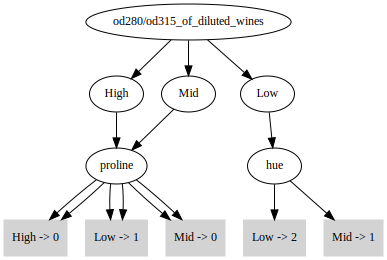

Configuration,Accuracy,Precision,Recall,F1
bin_prune_tune,0.925926,0.925253,0.912698,0.916915


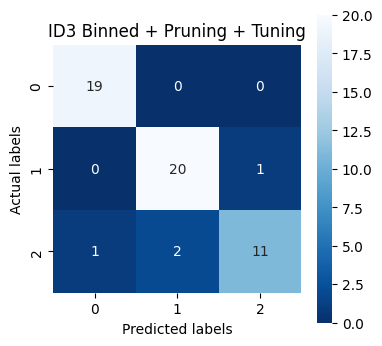

In [11]:
# Apply tuned pruning parameters to balance model complexity and generalisation
# This configuration aims to achieve optimal performance
target_index = len(train_dataset[0]) - 1
tree = id3_pruned(train_dataset, target_index, features=feature_names[:],
                  max_depth=2, min_samples_split=10, min_samples_leaf=5)

graph = draw_tree(tree)
display(graph)
graph.render("outputs/trees/id3_binned_pruned_tuned", format="png", cleanup=True)

y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_bin_prune_tune = evaluate("bin_prune_tune", y_true, y_pred)

display(pd.DataFrame([results_bin_prune_tune]).style.hide(axis="index"))

plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Binned + Pruning + Tuning",
    save_path="outputs/confusion_matrices/05_binned_pruned_tuned.png",
    show=True
)

**Observation:**  

Binning enables ID3 to effectively handle continuous data, leading to major improvement in performance. Carefully tuned pruning further enhances generalisation by removing unnecessary splits. This demonstrates the importance of both feature preprocessing and model complexity.

**Binned ID3 + Over-Pruning**

In [12]:
# Apply aggressive pruning to demonstrate underfitting
# Extreme constraints force the tree to be overly simple
target_index = len(train_dataset[0]) - 1
tree = id3_pruned(train_dataset, target_index, features=feature_names[:],
                  max_depth=1, min_samples_split=20, min_samples_leaf=10)

y_true, y_pred = get_predictions(tree, test_dataset, feature_names)
results_bin_overprune = evaluate("bin_overprune", y_true, y_pred)

plot_confusion_matrix(
    y_true,
    y_pred,
    title="ID3 Binned + Over-Pruning",
    save_path="outputs/confusion_matrices/06_binned_overpruned.png",
    show=False
)

### Sklearn Decision Tree Variants

####Sklearn Decision Tree (Raw Values)

Configuration,Accuracy,Precision,Recall,F1
sklearn_raw,0.962963,0.967305,0.958647,0.962359


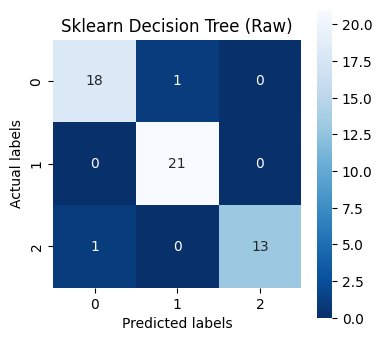

In [13]:
# Reload dataset to apply decision tree to original dataset
wine = load_wine()
X = wine.data
y = wine.target

# Train/test split (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train sklearn decision tree on raw continuous features
# Serves as benchmark using an industry-standard implementation
tree_sklearn = DecisionTreeClassifier(random_state=42)
tree_sklearn.fit(X_train, y_train)

y_pred = tree_sklearn.predict(X_test)
y_true = y_test.tolist()

results_sklearn = evaluate("sklearn_raw", y_true, y_pred)
display(pd.DataFrame([results_sklearn]).style.hide(axis="index"))

plot_confusion_matrix(
    y_true,
    y_pred,
    title="Sklearn Decision Tree (Raw)",
    save_path="outputs/confusion_matrices/07_sklearn_raw.png",
    show=True
)

**Observation:**  
The sklearn decision tree achieves strong performance when trained on raw continuous features, demonstrating its ability to learn precise decision boundaries directly from the data. This performance is enabled by its use of optimal split threshold selection, which allows the model to capture detailed patterns in continuous variables without requiring additional preprocessing.

####Sklearn Decision Tree (Discretised + Label-encoded)

Configuration,Accuracy,Precision,Recall,F1
sklearn_binned_encoded,0.796296,0.838735,0.804094,0.797222


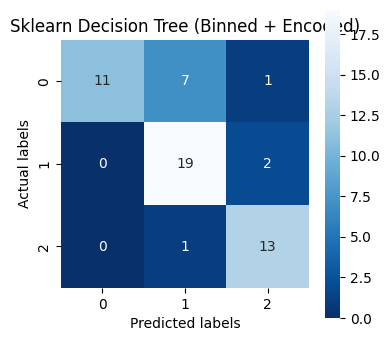

In [14]:
# Prepare discretised dataset for sklearn (convert categorical bins to numeric labels)
# Required because sklearn models expect numerical input
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]

X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]

# Copy data so original isn't modified
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

encoders = {}

# Encode discretised categorical bins into integers for sklearn compatibility
for col in X_train.columns:
  le = LabelEncoder()
  X_train_enc[col] = le.fit_transform(X_train[col])
  X_test_enc[col] = le.transform(X_test[col])
  encoders[col] = le

# Train sklearn decision tree with same constraints as tuned ID3
sklearn_binned = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

sklearn_binned.fit(X_train_enc, y_train)

y_pred = sklearn_binned.predict(X_test_enc)
y_true = y_test.tolist()

results_sklearn_bin = evaluate("sklearn_binned_encoded", y_true, y_pred)
display(pd.DataFrame([results_sklearn_bin]).style.hide(axis="index"))

plot_confusion_matrix(
    y_true,
    y_pred,
    title="Sklearn Decision Tree (Binned + Encoded)",
    save_path="outputs/confusion_matrices/08_sklearn_binned_encoded.png",
    show=True
)

**Observation:**  
Applying the same discretisation and pruning constraints to the sklearn model results in a noticeable drop in performance compared to both the raw sklearn model and the tuned ID3.  This suggests that while discretisation significantly benefits the custom ID3 implementation (which requires categorical inputs), it introduces information loss for sklearn’s decision tree, which is designed to handle continuous features.

## Comparison of Results

In [19]:
all_results = [
    results_plain,
    results_plain_prune,
    results_bin,
    results_bin_prune,
    results_bin_prune_tune,
    results_bin_overprune,
    results_sklearn,
    results_sklearn_bin
]

names = [
    "Plain ID3",
    "Plain ID3 + Pruning",
    "Binned ID3",
    "Binned ID3 + Pruning",
    "Binned ID3 + Pruning + Tuning",
    "Binned ID3 + Over-Pruning",
    "Sklearn DT (Raw Values)",
    "Sklearn DT (Binned + Encoded)"
]

df_results = pd.DataFrame(all_results)
df_results["Configuration"] = names

# Preserve original order
df_results = df_results[["Configuration", "Accuracy", "Precision", "Recall", "F1"]]

for col in ["Accuracy", "Precision", "Recall", "F1"]:
    df_results[col] = (df_results[col] * 100).round(2).astype(str) + "%"

# Split into two groups and display
sklearn_results = df_results[df_results["Configuration"].str.startswith("Sklearn")]
custom_results = df_results[~df_results["Configuration"].str.startswith("Sklearn")]

print("Custom ID3 Variants")
display(custom_results.style.hide(axis="index"))

print("\nSklearn Decision Tree")
display(sklearn_results.style.hide(axis="index"))

Custom ID3 Variants


Configuration,Accuracy,Precision,Recall,F1
Plain ID3,44.44%,56.15%,43.78%,42.03%
Plain ID3 + Pruning,37.04%,25.1%,33.75%,28.1%
Binned ID3,85.19%,87.32%,82.54%,83.0%
Binned ID3 + Pruning,90.74%,90.76%,88.89%,89.34%
Binned ID3 + Pruning + Tuning,92.59%,92.53%,91.27%,91.69%
Binned ID3 + Over-Pruning,62.96%,64.89%,65.16%,64.82%



Sklearn Decision Tree


Configuration,Accuracy,Precision,Recall,F1
Sklearn DT (Raw Values),96.3%,96.73%,95.86%,96.24%
Sklearn DT (Binned + Encoded),79.63%,83.87%,80.41%,79.72%


**Observation:**

The sklearn decision tree trained on raw continuous features achieves the highest performance among all models. This is because sklearn's implementation can directly evaluate optimal split thresholds on continuous variables, preserving full feature information.

In contrast, the custom ID3 requires discretisation, which introduces information loss and limits split flexibility. This explains the performance gap between sklearn (raw) and the best ID3 variant.